In [71]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Parameters
e0 = 8.854187817e-12  # Vacuum permittivity (F/m)
mu0 = 4 * np.pi * 1e-7  # Vacuum permeability (H/m)
vp = 1 / np.sqrt(e0 * mu0)

# free space
e1 = 1 * e0
mu1 = 1 * mu0

# dieletric slab
e2 = 2 * e0 
mu2 = 1 * mu0 

# second dielectric to the right 
e3 = 4 * e0
mu3 = 1 * mu0

lambda0 = 0.3
dx = lambda0 / (20 * np.sqrt(e1 / e0))
dt = dx / vp

L = 3
Nx = int(L / dx) + 1
Nt = 600
T = Nt * dt

tau = 0.8e-9 / dt

# inicio e fim do slab
d = lambda0 / (2 * np.sqrt(e2 / e0)) # tamanho do slab
center = Nx // 2
center_m = center * dx
start_d = center_m - d / 2
end_d = center_m + d / 2

def gaussian(n):
    return np.exp(-(n - 3 * tau)**2 / tau**2)

# campos
Ey = np.zeros((Nt, Nx))
Hz = np.zeros((Nt, Nx))

# arrays para as propriedades dos materiais
e_medium = np.zeros(Nx)
mu_medium = np.zeros(Nx)

for i in range(Nx):
    xcoord = i * dx
    if xcoord < start_d: # ar livre
        e_medium[i] = e1
        mu_medium[i] = mu1
    elif start_d <= xcoord <= end_d: # slab
        e_medium[i] = e2
        mu_medium[i] = mu2
    elif xcoord > end_d: # segundo dieletrico
        e_medium[i] = e3
        mu_medium[i] = mu3

# marcha no tempo
for n in range(Nt - 1):

    # atualiza o H
    for i in range(Nx - 1):
        Hz[n+1, i] = Hz[n, i] + (dt / (mu_medium[i] * dx)) * (Ey[n, i+1] - Ey[n, i])

    # atualiza o E
    for i in range(1, Nx - 1):
        # por causa do i-1 no final que o range começa em 1
        Ey[n+1, i] = Ey[n, i] + (dt / (e_medium[i] * dx)) * (Hz[n+1, i] - Hz[n+1, i-1])

    # condição de contorno
    if n < 6 * tau:  # só aplica a fonte nos primeiros instantes
        Ey[n+1, 0] = gaussian(n+1) # esquerda
    else: # condicao de contorno absorvente
        Ey[n+1, 0] = Ey[n, 1] + (vp * dt - dx) / (vp * dt + dx) * (Ey[n+1, 1] - Ey[n, 0])  # absorvente à esquerda
    Ey[n+1, -1] = Ey[n, -2] - (vp * dt - dx) / (vp * dt + dx) * (Ey[n+1, -2] - Ey[n, -1])  # absorvente à direita



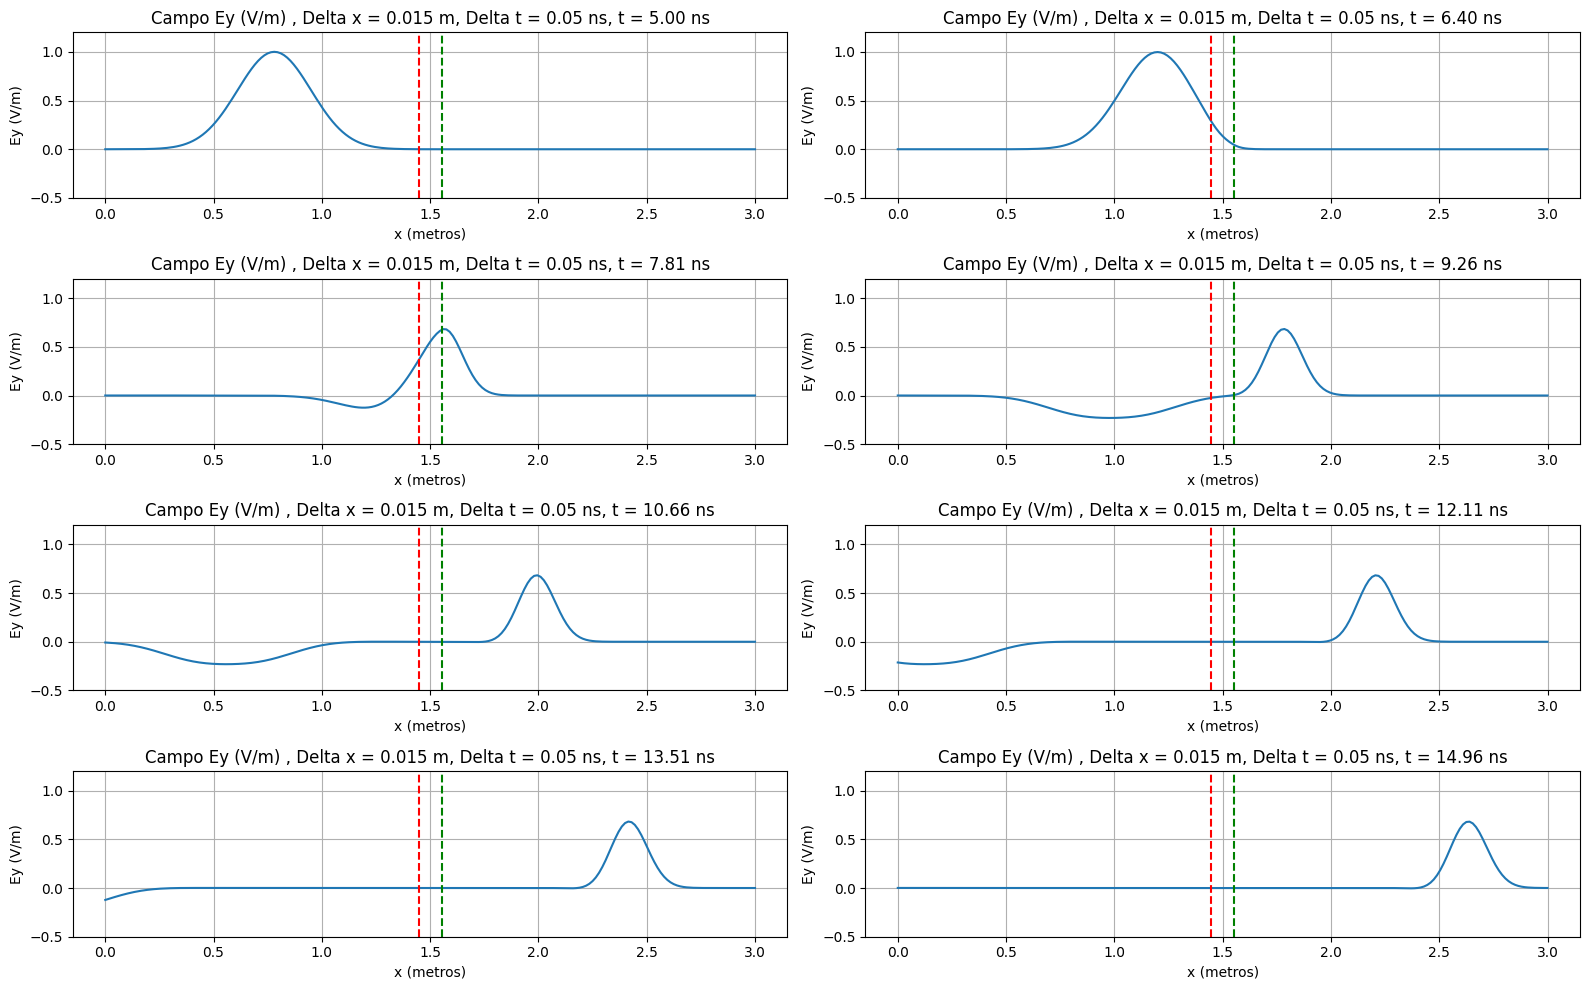

In [82]:
# Plot a few time snapshots
t_list = np.linspace(100, Nt // 2 - 1, 8, dtype=int)
x_grid = np.linspace(0, L, Nx)

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(4, 2, figsize=(16, 10))

for i, ax in enumerate(axes.flat):
    ax.plot(x_grid, Ey[t_list[i], :], label=f"t = {t_list[i]*dt*1e9:.2f} ns")
    ax.axvline(x=start_d, color='red', linestyle='--', label='Início do slab')
    ax.axvline(x=end_d, color='green', linestyle='--', label='Fim do slab')
    ax.set_title(f"Campo Ey (V/m) , Delta x = {dx} m, Delta t = {dt*1e9:.2f} ns, t = {t_list[i]*dt*1e9:.2f} ns")
    ax.set_xlabel("x (metros)")
    ax.set_ylabel(f"Ey (V/m)")
    ax.set_ylim(-0.5, 1.2)
    ax.grid()

plt.tight_layout() # Adjusts spacing between subplots
plt.show()

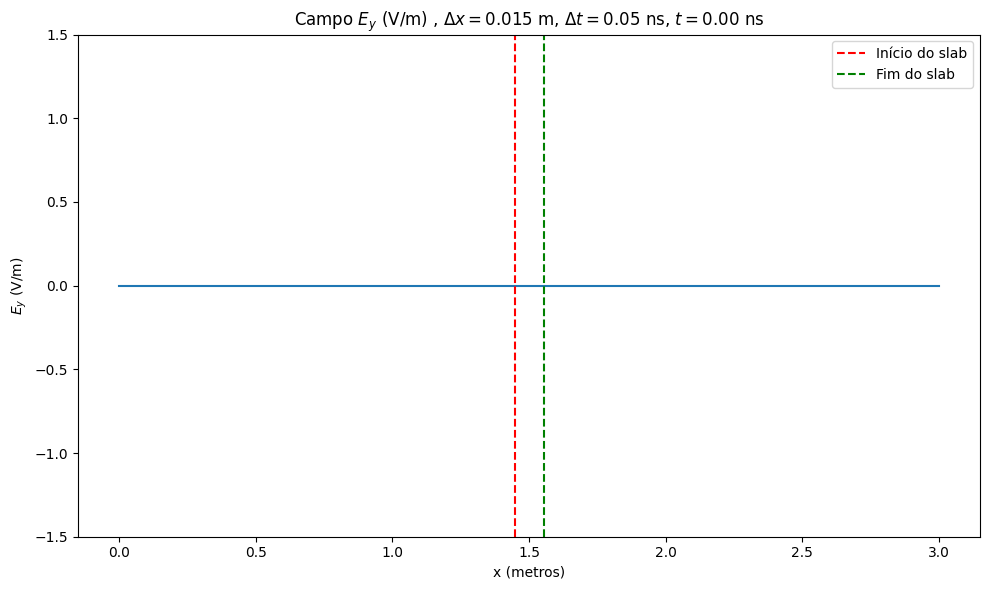

In [79]:
x_grid = np.linspace(0, L, Nx)

# Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(x_grid, np.zeros(Nx))
ax.axvline(x=start_d, color='red', linestyle='--', label='Início do slab')
ax.axvline(x=end_d, color='green', linestyle='--', label='Fim do slab')
ax.set_title(fr"Campo $E_y$ (V/m) , $\Delta x = {dx}$ m, $\Delta t = {dt*1e9:.2f}$ ns, $t = {0*dt*1e9:.2f}$ ns")
ax.set_xlabel("x (metros)")
ax.set_ylabel(r"$E_y$ (V/m)")
ax.set_ylim(-1.5, 1.5)
ax.legend()

plt.tight_layout() # Adjusts spacing between subplots
plt.show()